# MFDFA-Only Model Training and Evaluation

This notebook trains and evaluates baseline ML models using ONLY multifractal features (along with core metadata).
It uses a hierarchical approach:
1. Binary classification (Healthy vs Pathological)
2. Multi-class classification (Specific Pathology)

Finally, it performs hyperparameter tuning on the best models for both stages.

In [33]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sys.path.append("..")
from src.features import FeatureOptions, load_feature_tables

In [34]:
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Keep this small for quick iteration; set to None for full training set
MAX_SAMPLES_PER_CLASS = 200

opts = FeatureOptions(
    prefix=Path(".."),
    include_splits=True,
    random_seed=RANDOM_SEED,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
)

opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_opensmile=WindowsPath('data/processed/features/opensmile_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, max_samples_per_class=200, normalize_audio=True, target_sample_rate=None, mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=1.0, mfdfa_num_scales=20)

In [35]:
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)

for name, df in tables.items():
    print(f"{name}: {df.shape}")

core_df = tables["core"].copy()
multifractal_df = tables["multifractal"].copy()
splits_df = tables.get("splits", pd.DataFrame())

Pathologies:   0%|          | 0/7 [00:00<?, ?pathology/s]
















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































core: (1214, 18)
acoustic: (1214, 87)
multifractal: (1214, 17)
opensmile: (1214, 91)
splits: (1214, 3)


In [36]:
# Build one training table
df = core_df.merge(multifractal_df, on="sample_key", how="left")
if not splits_df.empty:
    df = df.merge(splits_df, on="sample_key", how="left")

# Filter to successfully extracted samples
if "feature_status" in df.columns:
    df = df[df["feature_status"].isin(["ok", "partial_failure"])].copy()
if "mf_status" in df.columns:
    df = df[df["mf_status"] == "ok"].copy()

df.shape

(1214, 36)

In [37]:
df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,...,mf_alpha_mean,mf_alpha_std,mf_spectrum_width,mf_spectrum_peak_alpha,mf_spectrum_peak_f,mf_spectrum_asymmetry,mf_num_scales,mf_num_q,split,split_seed
0,Morbus Parkinson::1580::vowels::a_h,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_h,m,...,0.835938,0.319092,0.792299,0.615091,0.977071,0.182400,20,10,train,42
1,Morbus Parkinson::1580::vowels::a_l,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_l,m,...,0.814805,0.292166,0.752851,0.629105,0.973514,0.224294,20,10,train,42
2,Morbus Parkinson::1580::vowels::a_lhl,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_lhl,m,...,0.800038,0.343014,0.854544,0.572759,0.967594,0.208532,20,10,train,42
3,Morbus Parkinson::1580::vowels::a_n,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_n,m,...,0.814805,0.292166,0.752851,0.629105,0.973514,0.224294,20,10,train,42
4,Morbus Parkinson::1580::vowels::i_h,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,i_h,m,...,0.862010,0.228141,0.596956,0.724345,0.974918,0.244982,20,10,train,42


In [38]:
# Show the target classes
print("Target classes:")
print(df["pathology_en"].value_counts())

Target classes:
pathology_en
Phonationsknötchen                     200
Reinke Ödem                            200
recurrent laryngeal nerve paralysis    200
spasmodic dysphonia                    200
vocal fold polyp                       200
healthy                                200
parkinson's disease                     14
Name: count, dtype: int64


In [39]:
# Select target and features
target_col = "pathology_de" if "pathology_de" in df.columns else "pathology_en"

exclude_cols = {
    "sample_key",
    "duplicate_class_key",
    "recording_id",
    "speaker_id",
    "wav_path",
    "feature_status",
    "feature_error",
    "mf_status",
    "mf_error",
    "split",
    "split_seed",
    "pathology_de",
    "pathology_en",
    "is_healthy",
}

numeric_feature_cols = [
    c for c in df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]

categorical_feature_cols = [
    c for c in df.columns
    if c not in exclude_cols and (pd.api.types.is_string_dtype(df[c]) or pd.api.types.is_categorical_dtype(df[c]))
]

# Let's just use numeric features and 'sex' if it exists
if 'sex' in df.columns and 'sex' not in categorical_feature_cols:
    categorical_feature_cols.append('sex')

X = df[numeric_feature_cols + categorical_feature_cols].copy()
y_binary = df["is_healthy"].astype(int).copy() # 1 for healthy, 0 for pathological
y_multi = df[target_col].astype(str).copy()

print(f"Samples: {len(df)}")
print(f"Binary Classes: {y_binary.nunique()}")
print(f"Multi Classes: {y_multi.nunique()}")
print(f"Numeric features: {len(numeric_feature_cols)}")
print(f"Categorical features: {len(categorical_feature_cols)}")

Samples: 1214
Binary Classes: 2
Multi Classes: 7
Numeric features: 19
Categorical features: 3


C:\Users\mnand\AppData\Local\Temp\ipykernel_34228\1748606001.py:28: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if c not in exclude_cols and (pd.api.types.is_string_dtype(df[c]) or pd.api.types.is_categorical_dtype(df[c]))


In [40]:
# Train/test split: prefer precomputed split table when available
if "split" in df.columns and df["split"].notna().any():
    train_mask = df["split"] == "train"
    val_mask = df["split"] == "val"
    test_mask = df["split"] == "test"

    X_train = X[train_mask | val_mask]
    y_bin_train = y_binary[train_mask | val_mask]
    y_multi_train = y_multi[train_mask | val_mask]
    
    X_test = X[test_mask]
    y_bin_test = y_binary[test_mask]
    y_multi_test = y_multi[test_mask]

    if len(X_test) == 0:
        X_train, X_test, y_bin_train, y_bin_test, y_multi_train, y_multi_test = train_test_split(
            X, y_binary, y_multi, test_size=0.2, stratify=y_multi, random_state=RANDOM_SEED
        )
else:
    X_train, X_test, y_bin_train, y_bin_test, y_multi_train, y_multi_test = train_test_split(
        X, y_binary, y_multi, test_size=0.2, stratify=y_multi, random_state=RANDOM_SEED
    )

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1057, 22)
Test shape: (157, 22)


In [41]:
# Shared preprocessing for numeric and categorical feature space
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_feature_cols),
        ("cat", categorical_transformer, categorical_feature_cols),
    ],
    remainder="drop",
)

In [42]:
models = {
    "LogReg": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample",
        n_jobs=-1,
    ),
    "SVM-RBF": SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced"),
    "XGBoost": XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=RANDOM_SEED, n_jobs=-1, class_weight="balanced", verbose=-1),
}

results_bin = []
trained_pipelines_bin = {}

print("--- Binary Classification (Healthy vs Pathological) ---")
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_bin_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_bin_test, y_pred)
    bacc = balanced_accuracy_score(y_bin_test, y_pred)
    f1m = f1_score(y_bin_test, y_pred, average="macro", zero_division=0)

    results_bin.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1_macro": f1m,
    })

    trained_pipelines_bin[name] = (pipe, y_pred)

results_bin_df = pd.DataFrame(results_bin).sort_values(by="f1_macro", ascending=False)
display(results_bin_df)

--- Binary Classification (Healthy vs Pathological) ---


g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,balanced_accuracy,f1_macro
2,SVM-RBF,0.541401,0.604913,0.520204
4,LightGBM,0.681529,0.500689,0.497568
3,XGBoost,0.719745,0.505969,0.492954
0,LogReg,0.503185,0.560606,0.483029
1,RandomForest,0.764331,0.515381,0.481015


In [43]:
# Multi-class classification on pathological samples only
pathological_train_mask = y_bin_train == 0
pathological_test_mask = y_bin_test == 0

X_train_patho = X_train[pathological_train_mask]
y_multi_train_patho = y_multi_train[pathological_train_mask]

X_test_patho = X_test[pathological_test_mask]
y_multi_test_patho = y_multi_test[pathological_test_mask]

# Encode labels for XGBoost/LightGBM
le = LabelEncoder()
y_multi_train_patho_enc = le.fit_transform(y_multi_train_patho)
y_multi_test_patho_enc = le.transform(y_multi_test_patho)

results_multi = []
trained_pipelines_multi = {}

print("--- Multi-class Classification (Specific Pathology) ---")
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train_patho, y_multi_train_patho_enc)
    y_pred_enc = pipe.predict(X_test_patho)
    y_pred = le.inverse_transform(y_pred_enc)

    acc = accuracy_score(y_multi_test_patho, y_pred)
    bacc = balanced_accuracy_score(y_multi_test_patho, y_pred)
    f1m = f1_score(y_multi_test_patho, y_pred, average="macro", zero_division=0)

    results_multi.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1_macro": f1m,
    })

    trained_pipelines_multi[name] = (pipe, y_pred)

results_multi_df = pd.DataFrame(results_multi).sort_values(by="f1_macro", ascending=False)
display(results_multi_df)

--- Multi-class Classification (Specific Pathology) ---


g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature na

,model,accuracy,balanced_accuracy,f1_macro
1,RandomForest,0.206612,0.202742,0.190044
0,LogReg,0.206612,0.193210,0.157119
3,XGBoost,0.173554,0.181441,0.155306
2,SVM-RBF,0.198347,0.183842,0.142955
4,LightGBM,0.181818,0.185330,0.133829


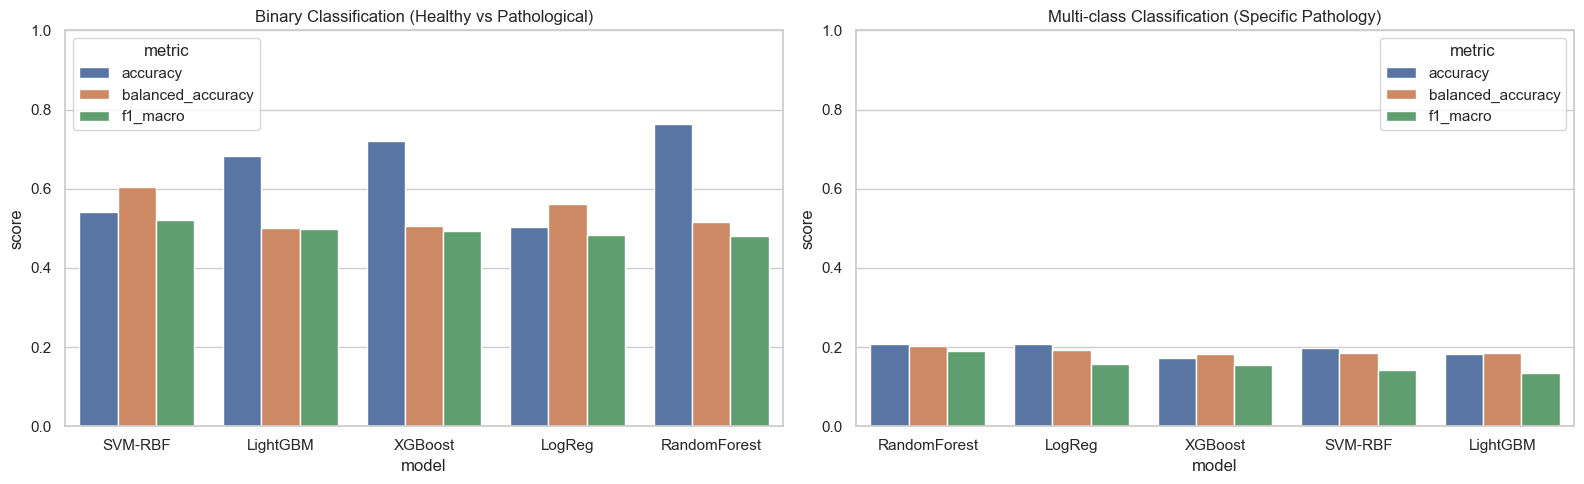

In [44]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_df_bin = results_bin_df.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df_bin, x="model", y="score", hue="metric", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Binary Classification (Healthy vs Pathological)")

plot_df_multi = results_multi_df.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df_multi, x="model", y="score", hue="metric", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("Multi-class Classification (Specific Pathology)")

plt.tight_layout()
plt.show()

In [45]:
best_model_name_bin = results_bin_df.iloc[0]["model"]
best_pipe_bin, best_pred_bin = trained_pipelines_bin[best_model_name_bin]

print(f"Best Binary Model: {best_model_name_bin}")
print(classification_report(y_bin_test, best_pred_bin, zero_division=0))

best_model_name_multi = results_multi_df.iloc[0]["model"]
best_pipe_multi, best_pred_multi = trained_pipelines_multi[best_model_name_multi]

print(f"\nBest Multi-class Model: {best_model_name_multi}")
print(classification_report(y_multi_test_patho, best_pred_multi, zero_division=0))

Best Binary Model: SVM-RBF
              precision    recall  f1-score   support

           0       0.86      0.49      0.62       121
           1       0.30      0.72      0.42        36

    accuracy                           0.54       157
   macro avg       0.58      0.60      0.52       157
weighted avg       0.73      0.54      0.57       157


Best Multi-class Model: RandomForest
                        precision    recall  f1-score   support

   Phonationsknötchen       0.00      0.00      0.00         0
          Reinke Ödem       0.57      0.36      0.44        36
       Rekurrensparese       0.35      0.28      0.31        25
Spasmodische Dysphonie       0.25      0.08      0.12        38
      Stimmlippenpolyp       0.07      0.09      0.08        22

              accuracy                           0.21       121
             macro avg       0.25      0.16      0.19       121
          weighted avg       0.33      0.21      0.25       121



In [46]:
# Hyperparameter Tuning for the best binary model
print(f"--- Hyperparameter Tuning (Binary Classification: {best_model_name_bin}) ---")

# Define parameter grids for different models
param_grids = {
    "LogReg": {
        "model__C": [0.01, 0.1, 1.0, 10.0],
        "model__solver": ["lbfgs", "liblinear"]
    },
    "RandomForest": {
        "model__n_estimators": [100, 200, 400],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10]
    },
    "SVM-RBF": {
        "model__C": [0.1, 1.0, 3.0, 10.0],
        "model__gamma": ["scale", "auto", 0.1, 0.01]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.1, 0.2]
    },
    "LightGBM": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [-1, 5, 10],
        "model__learning_rate": [0.01, 0.1, 0.2]
    }
}

if best_model_name_bin in param_grids:
    param_grid_bin = param_grids[best_model_name_bin]
    
    # Re-create the pipeline with the best model type
    best_model_class_bin = models[best_model_name_bin]
    tune_pipe_bin = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", best_model_class_bin),
    ])
    
    grid_search_bin = GridSearchCV(
        tune_pipe_bin, param_grid_bin, cv=3, scoring="f1_macro", n_jobs=-1, verbose=1
    )
    
    grid_search_bin.fit(X_train, y_bin_train)
    
    print(f"Best parameters: {grid_search_bin.best_params_}")
    print(f"Best CV F1 Macro: {grid_search_bin.best_score_:.4f}")
    
    best_tuned_model_bin = grid_search_bin.best_estimator_
    y_pred_tuned_bin = best_tuned_model_bin.predict(X_test)
    
    print("\nTuned Binary Model Test Performance:")
    print(classification_report(y_bin_test, y_pred_tuned_bin, zero_division=0))
else:
    print(f"No parameter grid defined for {best_model_name_bin}")

--- Hyperparameter Tuning (Binary Classification: SVM-RBF) ---
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'model__C': 10.0, 'model__gamma': 0.1}
Best CV F1 Macro: 0.4756

Tuned Binary Model Test Performance:
              precision    recall  f1-score   support

           0       0.81      0.58      0.68       121
           1       0.28      0.56      0.37        36

    accuracy                           0.57       157
   macro avg       0.55      0.57      0.53       157
weighted avg       0.69      0.57      0.61       157



In [47]:
# Hyperparameter Tuning for the best multi-class model
print(f"--- Hyperparameter Tuning (Multi-class Classification: {best_model_name_multi}) ---")

if best_model_name_multi in param_grids:
    param_grid_multi = param_grids[best_model_name_multi]
    
    # Re-create the pipeline with the best model type
    best_model_class_multi = models[best_model_name_multi]
    tune_pipe_multi = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", best_model_class_multi),
    ])
    
    grid_search_multi = GridSearchCV(
        tune_pipe_multi, param_grid_multi, cv=3, scoring="f1_macro", n_jobs=-1, verbose=1
    )
    
    grid_search_multi.fit(X_train_patho, y_multi_train_patho_enc)
    
    print(f"Best parameters: {grid_search_multi.best_params_}")
    print(f"Best CV F1 Macro: {grid_search_multi.best_score_:.4f}")
    
    best_tuned_model_multi = grid_search_multi.best_estimator_
    y_pred_tuned_multi_enc = best_tuned_model_multi.predict(X_test_patho)
    y_pred_tuned_multi = le.inverse_transform(y_pred_tuned_multi_enc)
    
    print("\nTuned Multi-class Model Test Performance:")
    print(classification_report(y_multi_test_patho, y_pred_tuned_multi, zero_division=0))
else:
    print(f"No parameter grid defined for {best_model_name_multi}")

--- Hyperparameter Tuning (Multi-class Classification: RandomForest) ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best CV F1 Macro: 0.4101

Tuned Multi-class Model Test Performance:
                        precision    recall  f1-score   support

      Morbus Parkinson       0.00      0.00      0.00         0
   Phonationsknötchen       0.00      0.00      0.00         0
          Reinke Ödem       0.54      0.36      0.43        36
       Rekurrensparese       0.32      0.24      0.27        25
Spasmodische Dysphonie       0.23      0.08      0.12        38
      Stimmlippenpolyp       0.08      0.09      0.09        22

              accuracy                           0.20       121
             macro avg       0.19      0.13      0.15       121
          weighted avg       0.31      0.20      0.24       121

